In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

kerala = pd.read_csv("kerala_features.csv")

# These are the columns we feed INTO the model (inputs)
FEATURES = ["MONSOON", "PRE_MONSOON", "POST_MONSOON", "WINTER",
            "MONSOON_RATIO", "RAIN_ANOMALY", "PREV_YEAR_RAIN"]

# This is what we want the model to predict (output)
TARGET = "FLOOD_RISK"

X = kerala[FEATURES]   # X = inputs (convention in all of ML)
y = kerala[TARGET]     # y = output (convention in all of ML)

print(f"X shape: {X.shape}")   # rows x features
print(f"y shape: {y.shape}")   # rows
print(f"\nClass distribution:\n{y.value_counts()}")

X shape: (115, 7)
y shape: (115,)

Class distribution:
FLOOD_RISK
Medium    57
High      29
Low       29
Name: count, dtype: int64


In [2]:
# 80% of data for training, 20% for testing
# random_state=42 means the split is reproducible
# (same split every time you run it)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows:  {len(X_train)}")
print(f"Testing rows:   {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training rows:  92
Testing rows:   23

Train class distribution:
FLOOD_RISK
Medium    46
Low       23
High      23
Name: count, dtype: int64

Test class distribution:
FLOOD_RISK
Medium    11
High       6
Low        6
Name: count, dtype: int64


In [3]:
# n_estimators=100 → build 100 trees
# random_state=42  → reproducible results

model = RandomForestClassifier(n_estimators=100, random_state=42)

# .fit() is where learning happens
# The model reads X_train and y_train and finds patterns
model.fit(X_train, y_train)

print("Model trained ✓")
print(f"Number of trees: {model.n_estimators}")
print(f"Features used:   {model.n_features_in_}")

Model trained ✓
Number of trees: 100
Features used:   7


In [4]:
# .predict() uses the learned patterns on NEW data
y_pred = model.predict(X_test)

# Classification report shows precision, recall, f1 per class
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      1.00      1.00         6
      Medium       1.00      1.00      1.00        11

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



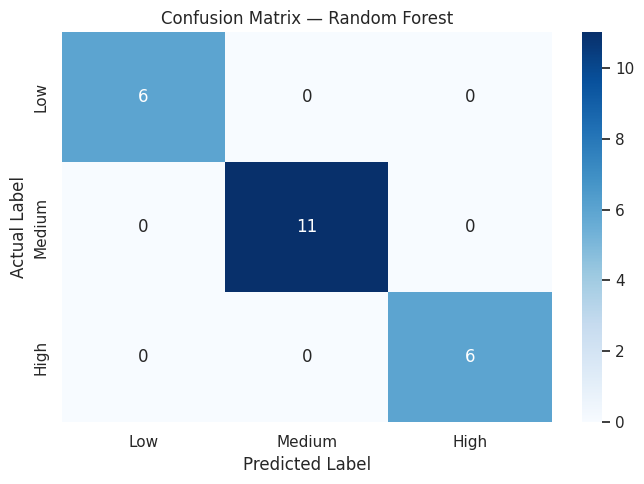

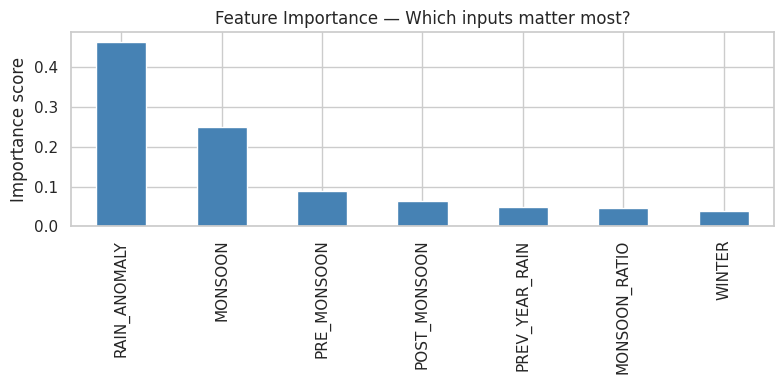

RAIN_ANOMALY      0.465
MONSOON           0.251
PRE_MONSOON       0.089
POST_MONSOON      0.063
PREV_YEAR_RAIN    0.050
MONSOON_RATIO     0.045
WINTER            0.038
dtype: float64


In [6]:
# Confusion matrix shows exactly where the model gets confused
labels = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
# Random Forest tells you which features it relied on most
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature Importance — Which inputs matter most?")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()

print(importances.round(3))

F1 scores across 5 folds:
  Fold 1: 0.950
  Fold 2: 1.000
  Fold 3: 1.000
  Fold 4: 0.955
  Fold 5: 1.000

Mean F1:  0.981
Std Dev:  0.023


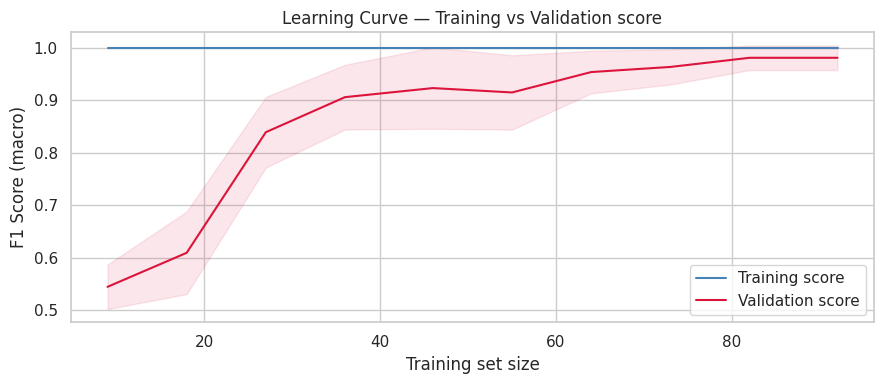

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold keeps class proportions in each fold
# (same idea as stratify=y from before)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold cross validation
scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")

print("F1 scores across 5 folds:")
for i, score in enumerate(scores, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean F1:  {scores.mean():.3f}")
print(f"Std Dev:  {scores.std():.3f}")
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(9, 4))
plt.plot(train_sizes, train_mean, label="Training score", color="steelblue")
plt.plot(train_sizes, val_mean,   label="Validation score", color="crimson")
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color="steelblue")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color="crimson")
plt.title("Learning Curve — Training vs Validation score")
plt.xlabel("Training set size")
plt.ylabel("F1 Score (macro)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Remove features derived from ANNUAL
# Keep only seasonal and monthly patterns
FEATURES_CLEAN = [
    "MONSOON", "PRE_MONSOON", "POST_MONSOON", "WINTER",
    "MONSOON_RATIO", "PREV_YEAR_RAIN"
]

# Notice: RAIN_ANOMALY is gone — it was derived from ANNUAL

X_clean = kerala[FEATURES_CLEAN]
y_clean = kerala[TARGET]

# Cross validate again with honest features
scores_clean = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_clean, y_clean, cv=cv, scoring="f1_macro"
)

print("=== Honest Model ===")
print("F1 scores across 5 folds:")
for i, score in enumerate(scores_clean, 1):
    print(f"  Fold {i}: {score:.3f}")

print(f"\nMean F1: {scores_clean.mean():.3f}")
print(f"Std Dev: {scores_clean.std():.3f}")

=== Honest Model ===
F1 scores across 5 folds:
  Fold 1: 0.822
  Fold 2: 0.808
  Fold 3: 0.691
  Fold 4: 0.866
  Fold 5: 0.815

Mean F1: 0.800
Std Dev: 0.058


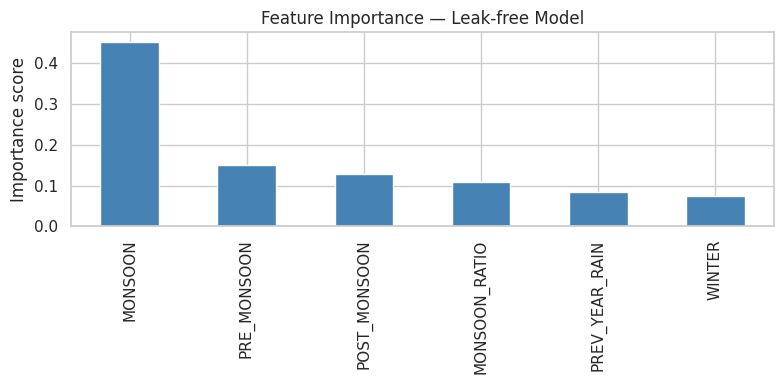

In [10]:
# Train on full data to see importances
honest_model = RandomForestClassifier(n_estimators=100, random_state=42)
honest_model.fit(X_clean, y_clean)

importances = pd.Series(
    honest_model.feature_importances_,
    index=FEATURES_CLEAN
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature Importance — Leak-free Model")
plt.ylabel("Importance score")
plt.tight_layout()
plt.show()